In [ ]:
# Load raw .pcd.bin
import numpy as np

# lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
lidar_bin = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
points = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)  # nuscenes = x,y,z,intensity,ring
points = points[:, :4]  # keep x,y,z,i
print(points.shape)
points[:5]


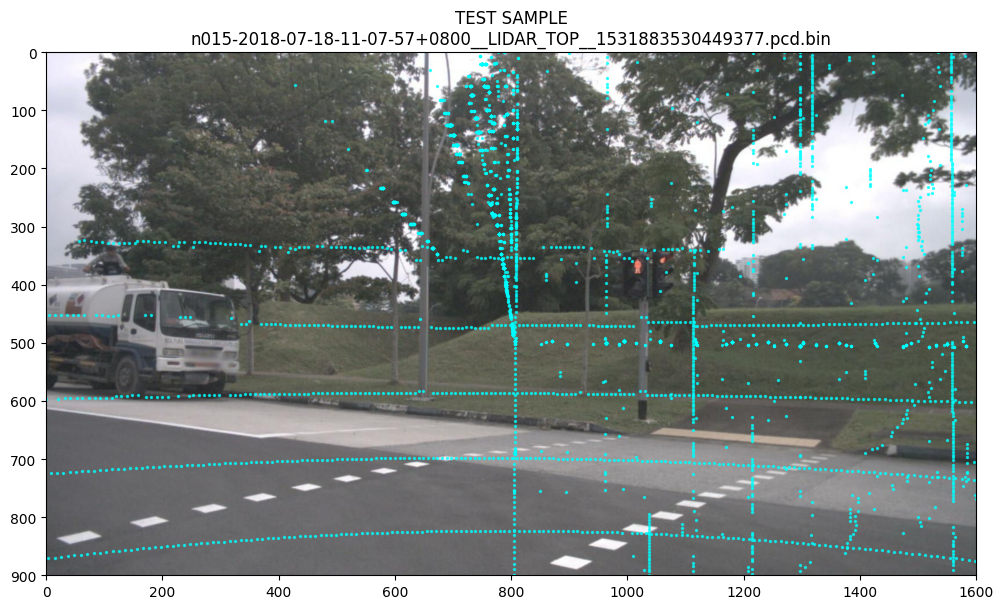

In [9]:
from pathlib import Path
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import transform_matrix, view_points
from pyquaternion import Quaternion
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------
# PATHS
# ----------------------
NUSCENES_ROOT = Path("~/Desktop/datasets/nuscenes").expanduser()
NUSCENES_VERSION = "v1.0-trainval"

LIDAR_FILE = "n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
lidar_path = NUSCENES_ROOT / "samples" / "LIDAR_TOP" / LIDAR_FILE


# ----------------------
# LOAD LIDAR
# ----------------------
def load_bin_pts(path):
    arr = np.fromfile(str(path), dtype=np.float32)
    return arr.reshape(-1, 4)

pts = load_bin_pts(lidar_path)
pts_xyz = pts[:, :3]

# ----------------------
# LOAD NUSCENES TEST
# ----------------------
nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(NUSCENES_ROOT), verbose=False)

# Find sample_token
sample_token = None
for sd in nusc.sample_data:
    if sd["channel"] == "LIDAR_TOP" and sd["filename"].endswith(LIDAR_FILE):
        sample_token = sd["sample_token"]
        cam_sd_token = nusc.get("sample", sample_token)["data"]["CAM_FRONT"]
        break

if sample_token is None:
    raise RuntimeError("Could not match lidar file to sample_token.")

cam_sd = nusc.get("sample_data", cam_sd_token)
cam_fname = cam_sd["filename"]  # e.g., "samples/CAM_FRONT/..."
img_path = NUSCENES_ROOT / cam_fname


# ----------------------
# PROJECT LIDAR TO CAMERA
# ----------------------
calib_cam = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
ego_cam   = nusc.get("ego_pose", cam_sd["ego_pose_token"])

sample = nusc.get("sample", sample_token)
lid_sd_token = sample["data"]["LIDAR_TOP"]
lid_sd = nusc.get("sample_data", lid_sd_token)
calib_lid = nusc.get("calibrated_sensor", lid_sd["calibrated_sensor_token"])
ego_lid   = nusc.get("ego_pose", lid_sd["ego_pose_token"])

# homogeneous coords
pts_h = np.vstack((pts_xyz.T, np.ones((1, pts_xyz.shape[0]))))

# Lidar->ego_lid
T_lid_ego = transform_matrix(calib_lid['translation'], Quaternion(calib_lid['rotation']))
pts_ego = T_lid_ego @ pts_h

# ego_lid->global
T_ego_glob = transform_matrix(ego_lid['translation'], Quaternion(ego_lid['rotation']))
pts_glob = T_ego_glob @ pts_ego

# global->ego_cam
T_ego_cam = transform_matrix(ego_cam['translation'], Quaternion(ego_cam['rotation']))
T_glob_ego_cam = np.linalg.inv(T_ego_cam)
pts_ego_cam = T_glob_ego_cam @ pts_glob

# ego_cam->camera
T_cam_ego = transform_matrix(calib_cam['translation'], Quaternion(calib_cam['rotation']))
T_ego_cam2 = np.linalg.inv(T_cam_ego)
pts_cam = T_ego_cam2 @ pts_ego_cam
pts_cam3 = pts_cam[:3, :]

# project
intrinsic = np.array(calib_cam["camera_intrinsic"])
uv = view_points(pts_cam3, intrinsic, normalize=True)
u, v = uv[0, :], uv[1, :]
z = pts_cam3[2, :]


# ----------------------
# LOAD IMAGE
# ----------------------
img = np.array(Image.open(img_path))
H, W = img.shape[:2]

# ----------------------
# VISUALIZATION
# ----------------------
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
plt.title(f"TEST SAMPLE\n{LIDAR_FILE}")
plt.xlim(0, W)
plt.ylim(H, 0)
plt.show()


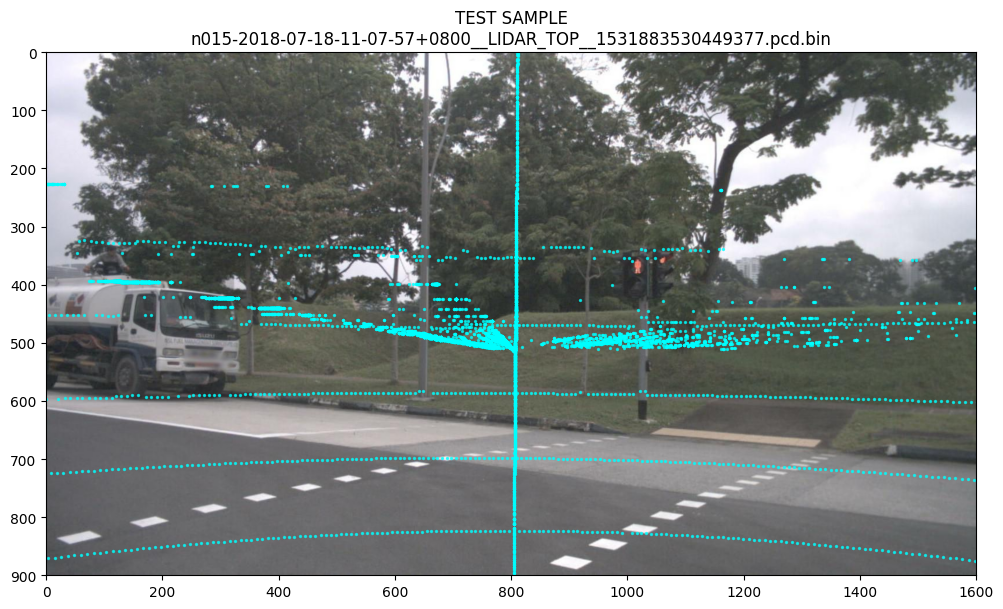

In [10]:
from pathlib import Path
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import transform_matrix, view_points
from pyquaternion import Quaternion
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------
# PATHS
# ----------------------
NUSCENES_ROOT = Path("~/Desktop/datasets/nuscenes").expanduser()
NUSCENES_VERSION = "v1.0-trainval"

LIDAR_FILE = "n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
lidar_path = NUSCENES_ROOT / "samples" / "LIDAR_TOP" / LIDAR_FILE



lidar_bin_root_path =  Path("~/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset").expanduser()
lidar_path = lidar_bin_root_path / LIDAR_FILE




# ----------------------
# LOAD LIDAR
# ----------------------
def load_bin_pts(path):
    arr = np.fromfile(str(path), dtype=np.float32)
    return arr.reshape(-1, 4)

pts = load_bin_pts(lidar_path)
pts_xyz = pts[:, :3]

# ----------------------
# LOAD NUSCENES TEST
# ----------------------
nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(NUSCENES_ROOT), verbose=False)

# Find sample_token
sample_token = None
for sd in nusc.sample_data:
    if sd["channel"] == "LIDAR_TOP" and sd["filename"].endswith(LIDAR_FILE):
        sample_token = sd["sample_token"]
        cam_sd_token = nusc.get("sample", sample_token)["data"]["CAM_FRONT"]
        break

if sample_token is None:
    raise RuntimeError("Could not match lidar file to sample_token.")

cam_sd = nusc.get("sample_data", cam_sd_token)
cam_fname = cam_sd["filename"]  # e.g., "samples/CAM_FRONT/..."
img_path = NUSCENES_ROOT / cam_fname


# ----------------------
# PROJECT LIDAR TO CAMERA
# ----------------------
calib_cam = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
ego_cam   = nusc.get("ego_pose", cam_sd["ego_pose_token"])

sample = nusc.get("sample", sample_token)
lid_sd_token = sample["data"]["LIDAR_TOP"]
lid_sd = nusc.get("sample_data", lid_sd_token)
calib_lid = nusc.get("calibrated_sensor", lid_sd["calibrated_sensor_token"])
ego_lid   = nusc.get("ego_pose", lid_sd["ego_pose_token"])

# homogeneous coords
pts_h = np.vstack((pts_xyz.T, np.ones((1, pts_xyz.shape[0]))))

# Lidar->ego_lid
T_lid_ego = transform_matrix(calib_lid['translation'], Quaternion(calib_lid['rotation']))
pts_ego = T_lid_ego @ pts_h

# ego_lid->global
T_ego_glob = transform_matrix(ego_lid['translation'], Quaternion(ego_lid['rotation']))
pts_glob = T_ego_glob @ pts_ego

# global->ego_cam
T_ego_cam = transform_matrix(ego_cam['translation'], Quaternion(ego_cam['rotation']))
T_glob_ego_cam = np.linalg.inv(T_ego_cam)
pts_ego_cam = T_glob_ego_cam @ pts_glob

# ego_cam->camera
T_cam_ego = transform_matrix(calib_cam['translation'], Quaternion(calib_cam['rotation']))
T_ego_cam2 = np.linalg.inv(T_cam_ego)
pts_cam = T_ego_cam2 @ pts_ego_cam
pts_cam3 = pts_cam[:3, :]

# project
intrinsic = np.array(calib_cam["camera_intrinsic"])
uv = view_points(pts_cam3, intrinsic, normalize=True)
u, v = uv[0, :], uv[1, :]
z = pts_cam3[2, :]


# ----------------------
# LOAD IMAGE
# ----------------------
img = np.array(Image.open(img_path))
H, W = img.shape[:2]

# ----------------------
# VISUALIZATION
# ----------------------
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
plt.title(f"TEST SAMPLE\n{LIDAR_FILE}")
plt.xlim(0, W)
plt.ylim(H, 0)
plt.show()


Total LiDAR points: 43400
Points inside CAM_FRONT FOV: 4518
Fraction in FOV: 0.104


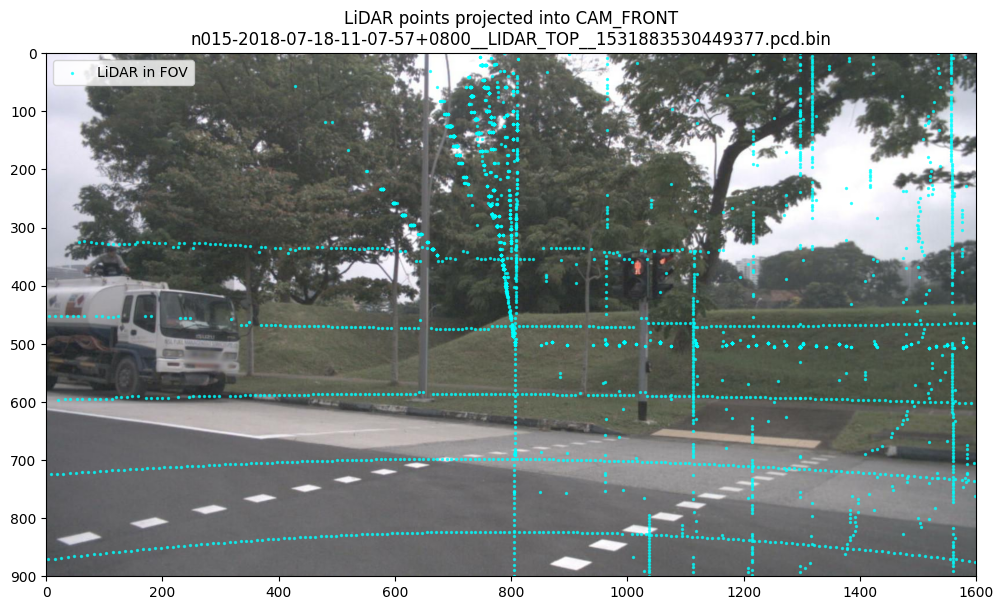

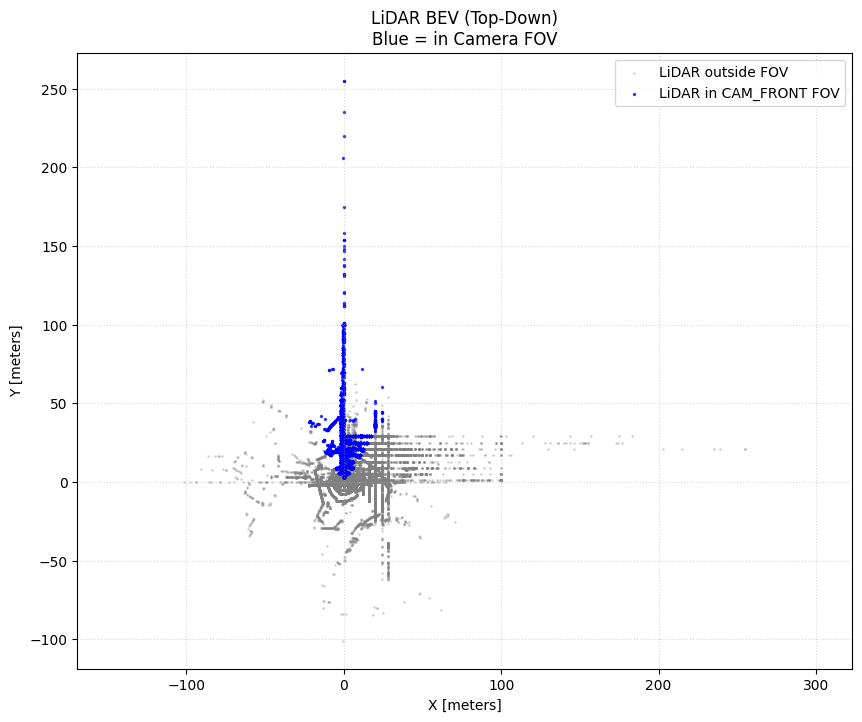

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# (Assuming all your code above is already run and the following vars exist:)
# pts_xyz, u, v, z, img, H, W

# ----------------------
# Step 1: Mask LiDAR points inside the camera FOV
# ----------------------
fov_mask = (u >= 0) & (u < W) & (v >= 0) & (v < H) & (z > 0)
in_fov_pts_xyz = pts_xyz[fov_mask]      # [N_in_fov, 3]
out_fov_pts_xyz = pts_xyz[~fov_mask]    # [N_out_fov, 3]

print(f"Total LiDAR points: {len(pts_xyz)}")
print(f"Points inside CAM_FRONT FOV: {len(in_fov_pts_xyz)}")
print(f"Fraction in FOV: {len(in_fov_pts_xyz) / len(pts_xyz):.3f}")

# ----------------------
# Step 2: Visualize camera image with FOV LiDAR points (already done, but here for completeness)
# ----------------------
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.scatter(u[fov_mask], v[fov_mask], s=2, c='cyan', alpha=0.7, label='LiDAR in FOV')
plt.title(f"LiDAR points projected into CAM_FRONT\n{LIDAR_FILE}")
plt.xlim(0, W)
plt.ylim(H, 0)
plt.legend()
plt.show()

# ----------------------
# Step 3: Visualize BEV (top-down) of all LiDAR points, highlighting FOV
# ----------------------
plt.figure(figsize=(10, 8))
plt.scatter(out_fov_pts_xyz[:, 0], out_fov_pts_xyz[:, 1], s=1, c='gray', alpha=0.25, label='LiDAR outside FOV')
plt.scatter(in_fov_pts_xyz[:, 0], in_fov_pts_xyz[:, 1], s=2, c='blue', alpha=0.7, label='LiDAR in CAM_FRONT FOV')
plt.xlabel('X [meters]')
plt.ylabel('Y [meters]')
plt.title('LiDAR BEV (Top-Down)\nBlue = in Camera FOV')
plt.axis('equal')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()


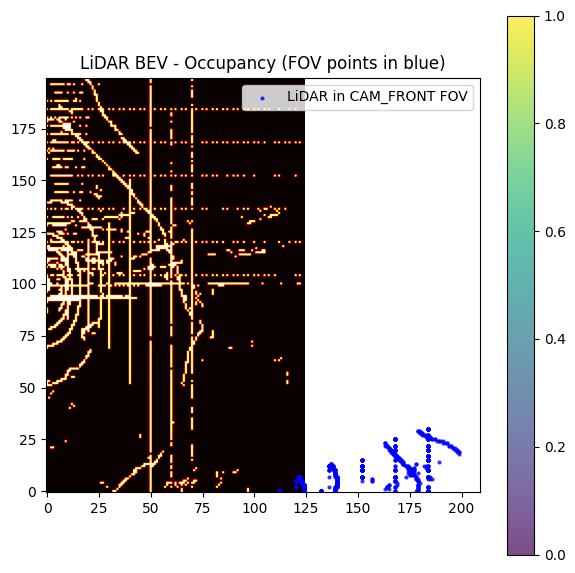

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your BEVSpec as before
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

# Example BEV config (adjust as needed)
bev_spec = BEVSpec(
    x_min=0.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)
points = pts
# 2. Compute BEV occupancy as before
def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T
    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]
    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)
    H, W = bev_spec.H, bev_spec.W
    bev_occ = np.zeros((H, W), dtype=np.float32)
    for px, py in zip(ix, iy):
        bev_occ[px, py] = 1
    return bev_occ, mask, ix, iy

bev_occ, bev_mask, ix, iy = lidar_to_bev(points, bev_spec)

# 3. Overlay: mark the FOV points on BEV (use your previously computed fov_mask)
# Make sure fov_mask is aligned with the original 'points' array
fov_points = points[fov_mask & bev_mask]
if len(fov_points) > 0:
    x_fov, y_fov = fov_points[:,0], fov_points[:,1]
    ix_fov = ((x_fov - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy_fov = ((y_fov - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)
else:
    ix_fov = np.array([], dtype=int)
    iy_fov = np.array([], dtype=int)

# 4. Visualize: BEV occupancy, overlaying FOV points as blue dots
plt.figure(figsize=(7,7))
plt.imshow(bev_occ.T, cmap="hot", origin="lower")
plt.scatter(iy_fov, ix_fov, s=4, c='blue', alpha=0.7, label='LiDAR in CAM_FRONT FOV')
plt.title("LiDAR BEV - Occupancy (FOV points in blue)")
plt.colorbar()
plt.legend()
plt.show()


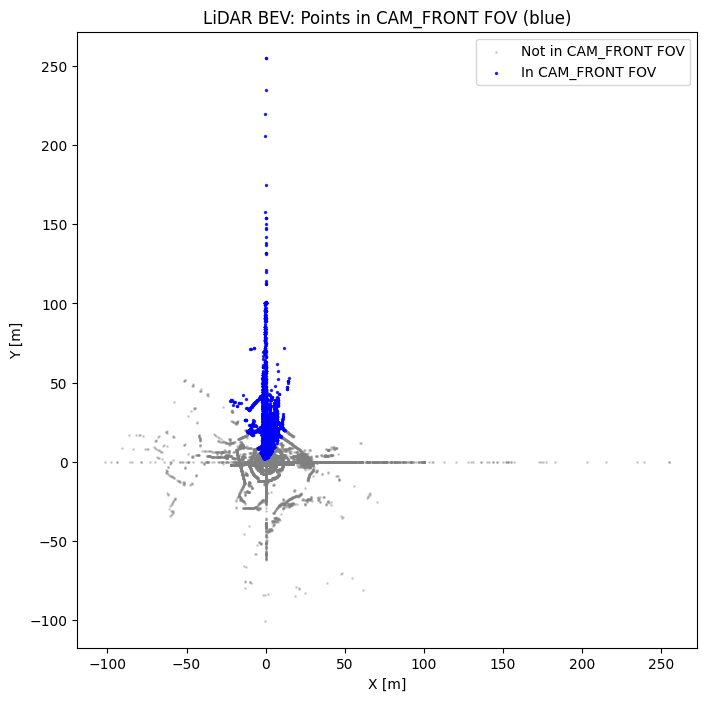

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# You already have these from earlier:
# pts: [N, 4] (x, y, z, intensity)
# u, v, z: projected pixel coords, depth
# W, H: image width/height

# 1. Create the flag
in_fov = (u >= 0) & (u < W) & (v >= 0) & (v < H) & (z > 0)  # Boolean array, True = inside CAM_FRONT FOV

# 2. Plot: All points in gray, FOV points in blue
plt.figure(figsize=(8, 8))
plt.scatter(pts[~in_fov, 0], pts[~in_fov, 1], s=1, c='gray', alpha=0.3, label='Not in CAM_FRONT FOV')
plt.scatter(pts[in_fov, 0], pts[in_fov, 1], s=2, c='blue', alpha=0.8, label='In CAM_FRONT FOV')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('LiDAR BEV: Points in CAM_FRONT FOV (blue)')
plt.legend()
plt.axis('equal')
plt.show()


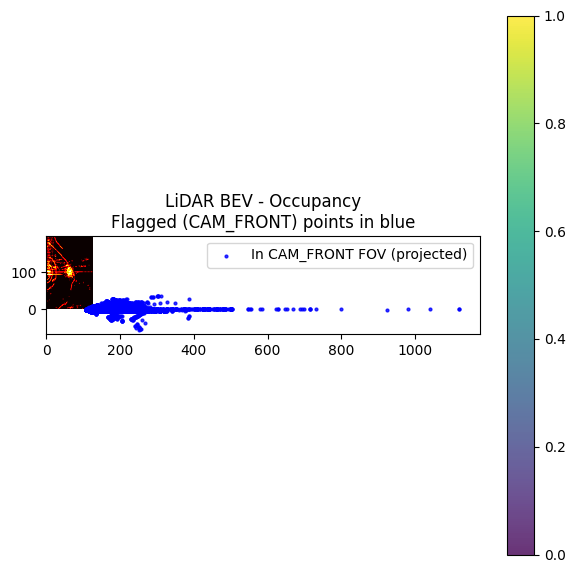

In [12]:
# --- 1. Compute BEV occupancy grid as before ---
bev_occ, _, _, _ = lidar_to_bev(pts, bev_spec)  # [H, W], as in your code

# --- 2. Compute grid indices for in-FOV points ---
ix_fov = ((pts[in_fov, 0] - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
iy_fov = ((pts[in_fov, 1] - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

# --- 3. Plot BEV occupancy map and overlay in-FOV points ---
plt.figure(figsize=(7,7))
plt.imshow(bev_occ.T, cmap="hot", origin="lower")  # transpose for image display

# Overlay flagged points (blue)
plt.scatter(iy_fov, ix_fov, s=4, c='blue', alpha=0.8, label='In CAM_FRONT FOV (projected)')

plt.title("LiDAR BEV - Occupancy\nFlagged (CAM_FRONT) points in blue")
plt.colorbar()
plt.legend()
plt.show()


In [13]:
print(f"bev_occ shape: {bev_occ.shape}")  # [H, W]
print(f"ix_fov min/max: {ix_fov.min()} / {ix_fov.max()}")
print(f"iy_fov min/max: {iy_fov.min()} / {iy_fov.max()}")


bev_occ shape: (125, 200)
ix_fov min/max: -55 / 36
iy_fov min/max: 108 / 1120


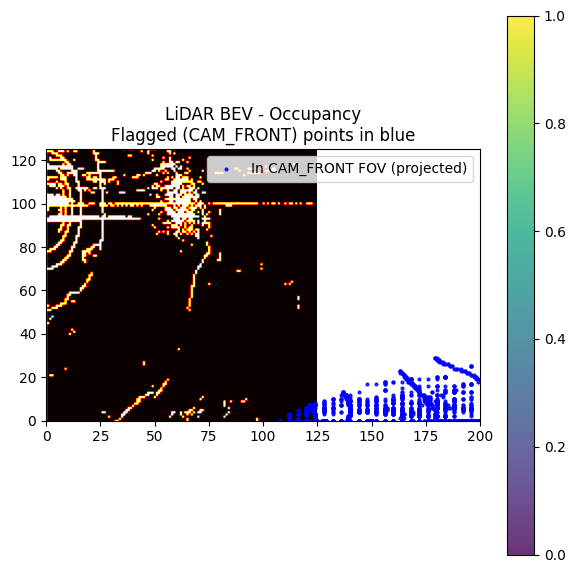

In [15]:
valid = (
    (ix_fov >= 0) & (ix_fov < bev_occ.shape[0]) &
    (iy_fov >= 0) & (iy_fov < bev_occ.shape[1])
)
ix_fov_valid = ix_fov[valid]
iy_fov_valid = iy_fov[valid]


def project_points_to_bev_grid(x, y, bev_spec):
    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(int)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(int)
    return ix, iy

# Compute and mask:
ix_fov, iy_fov = project_points_to_bev_grid(pts[in_fov, 0], pts[in_fov, 1], bev_spec)
valid = (
    (ix_fov >= 0) & (ix_fov < bev_occ.shape[0]) &
    (iy_fov >= 0) & (iy_fov < bev_occ.shape[1])
)



plt.figure(figsize=(7,7))
plt.imshow(bev_occ.T, cmap="hot", origin="lower")
plt.scatter(iy_fov_valid, ix_fov_valid, s=4, c='blue', alpha=0.8, label='In CAM_FRONT FOV (projected)')
plt.title("LiDAR BEV - Occupancy\nFlagged (CAM_FRONT) points in blue")
plt.xlim([0, bev_occ.shape[1]])
plt.ylim([0, bev_occ.shape[0]])
plt.colorbar()
plt.legend()
plt.show()
